In [1]:
# NBVAL_SKIP
from jax import config
#config.update("jax_enable_x64", True)
#config.update('jax_num_cpu_devices', 2)

In [2]:
#NBVAL_SKIP
import os

# Tell XLA to fake 2 host CPU devices
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=3'

# Only make GPU 0 and GPU 1 visible to JAX:
#os.environ['CUDA_VISIBLE_DEVICES'] = '1,2'

#os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]   = "false"

import jax

# Now JAX will list two CpuDevice entries
print(jax.devices())
# → [CpuDevice(id=0), CpuDevice(id=1)]

[CpuDevice(id=0)]


In [3]:
# NBVAL_SKIP
import os
#os.environ['SPS_HOME'] = '/mnt/storage/annalena_data/sps_fsps'
#os.environ['SPS_HOME'] = '/home/annalena/sps_fsps'
os.environ['SPS_HOME'] = '/Users/annalena/Documents/GitHub/fsps'
#os.environ['SPS_HOME'] = '/export/home/aschaibl/fsps'

# Load ssp template from FSPS

In [4]:
# NBVAL_SKIP
from rubix.spectra.ssp.factory import get_ssp_template
ssp_fsps = get_ssp_template("FSPS")

2025-10-08 16:22:52,464 - rubix - INFO - 
   ___  __  _____  _____  __
  / _ \/ / / / _ )/  _/ |/_/
 / , _/ /_/ / _  |/ /_>  <
/_/|_|\____/____/___/_/|_|


2025-10-08 16:22:52,465 - rubix - INFO - Rubix version: 0.0.post503+g060c53b49.d20251002
2025-10-08 16:22:52,465 - rubix - INFO - JAX version: 0.4.38
2025-10-08 16:22:52,465 - rubix - INFO - Running on [CpuDevice(id=0)] devices


In [5]:
# NBVAL_SKIP
age_values = ssp_fsps.age
print(age_values.shape)

metallicity_values = ssp_fsps.metallicity
print(metallicity_values.shape)

(107,)
(12,)


# Configure pipeline

In [6]:
# NBVAL_SKIP
from rubix.core.pipeline import RubixPipeline
import os
config = {
    "pipeline":{"name": "calc_gradient",},
    
    "logger": {
        "log_level": "DEBUG",
        "log_file_path": None,
        "format": "%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    },
    "data": {
        "name": "IllustrisAPI",
        "args": {
            "api_key": os.environ.get("ILLUSTRIS_API_KEY"),
            "particle_type": ["stars"],
            "simulation": "TNG50-1",
            "snapshot": 99,
            "save_data_path": "data",
        },
        
        "load_galaxy_args": {
        "id": 14,
        "reuse": True,
        },
        
        "subset": {
            "use_subset": True,
            "subset_size": 2,
        },
    },
    "simulation": {
        "name": "IllustrisTNG",
        "args": {
            "path": "data/galaxy-id-14.hdf5",
        },
    
    },
    "output_path": "output",

    "telescope":
        {"name": "TESTGRADIENT",
         "psf": {"name": "gaussian", "size": 5, "sigma": 0.6},
         "lsf": {"sigma": 1.2},
         "noise": {"signal_to_noise": 100,"noise_distribution": "normal"},
         },
    "cosmology":
        {"name": "PLANCK15"},
        
    "galaxy":
        {"dist_z": 0.1,
         "rotation": {"type": "edge-on"},
        },
        
    "ssp": {
        "template": {
            "name": "FSPS"
        },
        "dust": {
                "extinction_model": "Cardelli89",
                "dust_to_gas_ratio": 0.01,
                "dust_to_metals_ratio": 0.4,
                "dust_grain_density": 3.5,
                "Rv": 3.1,
            },
    },        
}

In [7]:
# NBVAL_SKIP
pipe = RubixPipeline(config)
inputdata = pipe.prepare_data()

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-10-08 16:22:53,302 - rubix - INFO - Getting rubix data...
2025-10-08 16:22:53,303 - rubix - INFO - Rubix galaxy file already exists, skipping conversion
/Users/annalena/miniconda3/envs/rubix/lib/python3.12/site-packages/jax/_src/numpy/lax_numpy.py:188: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)
/Users/annalena/Documents/GitHub/rubix/rubix/core/data.py:537: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and wil

# Gradient on the spectrum for each wavelenght

In [8]:
# NBVAL_SKIP
from rubix.pipeline import linear_pipeline as pipeline

pipeline_instance = RubixPipeline(config)

pipeline_instance._pipeline = pipeline.LinearTransformerPipeline(
    pipeline_instance.pipeline_config, 
    pipeline_instance._get_pipeline_functions()
)
pipeline_instance._pipeline.assemble()
pipeline_instance.func = pipeline_instance._pipeline.compile_expression()

/Users/annalena/Documents/GitHub/rubix/rubix/telescope/factory.py:26: UserWarning: No telescope config provided, using default stored in /Users/annalena/Documents/GitHub/rubix/rubix/telescope/telescopes.yaml
  warnings.warn(
2025-10-08 16:22:54,221 - rubix - INFO - Setting up the pipeline...
2025-10-08 16:22:54,221 - rubix - DEBUG - Pipeline Configuration: {'Transformers': {'rotate_galaxy': {'name': 'rotate_galaxy', 'depends_on': None, 'args': [], 'kwargs': {}}, 'spaxel_assignment': {'name': 'spaxel_assignment', 'depends_on': 'rotate_galaxy', 'args': [], 'kwargs': {}}, 'calculate_datacube_particlewise': {'name': 'calculate_datacube_particlewise', 'depends_on': 'spaxel_assignment', 'args': [], 'kwargs': {}}, 'convolve_psf': {'name': 'convolve_psf', 'depends_on': 'calculate_datacube_particlewise', 'args': [], 'kwargs': {}}, 'convolve_lsf': {'name': 'convolve_lsf', 'depends_on': 'convolve_psf', 'args': [], 'kwargs': {}}, 'apply_noise': {'name': 'apply_noise', 'depends_on': 'convolve_lsf',

In [9]:
# pick values
initial_age_index = 100
initial_metallicity_index = 5
age0 = age_values[initial_age_index]
Z0   = metallicity_values[initial_metallicity_index]

In [10]:
print(f"age0 = {age0}, Z0 = {Z0}")

age0 = 10.0, Z0 = 0.001420000335201621


In [11]:
# NBVAL_SKIP
import jax.numpy as jnp

inputdata.stars.age = jnp.array([age_values[initial_age_index], age_values[initial_age_index]])
inputdata.stars.metallicity = jnp.array([metallicity_values[initial_metallicity_index], metallicity_values[initial_metallicity_index]])
inputdata.stars.mass = jnp.array([[1.0], [1.0]])
inputdata.stars.velocity = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
inputdata.stars.coords = jnp.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])

In [12]:
import dataclasses
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

def spectrum_1d(age, Z, base_data, pipeline_instance):
    # broadcast per-star
    nstar = base_data.stars.age.shape[0]
    stars2 = dataclasses.replace(
        base_data.stars,
        age=jnp.full((nstar,), age),
        metallicity=jnp.full((nstar,), Z),
    )
    data2 = dataclasses.replace(base_data, stars=stars2)

    out = pipeline_instance.func(data2)

    cube = out.stars.datacube                        # shape (…, n_lambda)
    # collapse all non-wavelength axes, keep wavelength last
    spec = cube.reshape((-1, cube.shape[-1])).sum(axis=0)

    return jnp.ravel(spec)   

In [13]:
f = lambda a: spectrum_1d(a, Z0, inputdata, pipeline_instance)
ds_jvp = jax.jvp(f, (age0,), (1.0,))[1]
ds_fwd = jax.jacfwd(f)(age0)
print("||jvp - jacfwd|| =", jnp.linalg.norm(ds_jvp - ds_fwd))


2025-10-08 16:22:55,075 - rubix - INFO - Rotating galaxy with alpha=90.0, beta=0.0, gamma=0.0
2025-10-08 16:22:55,076 - rubix - INFO - Rotating galaxy for simulation: IllustrisTNG
2025-10-08 16:22:55,076 - rubix - WARNING - Gas not found in particle_type, only rotating stellar component.
2025-10-08 16:22:55,115 - rubix - INFO - Assigning particles to spaxels...
2025-10-08 16:22:55,122 - rubix - INFO - Calculating Data Cube (combined per‐particle)…
2025-10-08 16:22:55,231 - rubix - DEBUG - Datacube shape: (1, 1, 466)
2025-10-08 16:22:55,231 - rubix - INFO - Convolving with PSF...
2025-10-08 16:22:55,233 - rubix - INFO - Convolving with LSF...
2025-10-08 16:22:55,235 - rubix - INFO - Applying noise to datacube with signal to noise ratio: 100 and noise distribution: normal


||jvp - jacfwd|| = 0.0


In [14]:

eps = 1e-3 * float(age0)
fwd = lambda a: spectrum_1d(a, Z0, inputdata, pipeline_instance)
fd = (fwd(age0 + eps) - fwd(age0 - eps)) / (2*eps)
dspec = jax.jacfwd(lambda a: spectrum_1d(a, Z0, inputdata, pipeline_instance))(age0)


In [15]:
eps = 1e-3 * float(Z0)
fwd_Z = lambda Z: spectrum_1d(age0, Z, inputdata, pipeline_instance)
fd_Z = (fwd_Z(Z0 + eps) - fwd_Z(Z0 - eps)) / (2*eps)
dspec_Z = jax.jacfwd(lambda Z: spectrum_1d(age0, Z, inputdata, pipeline_instance))(Z0)

In [16]:
spec0 = spectrum_1d(age0, Z0, inputdata, pipeline_instance)

In [17]:
import matplotlib.pyplot as plt
wave = pipe.telescope.wave_seq

In [20]:
diff_Z = dspec_Z - fd_Z
diff_a = dspec - fd

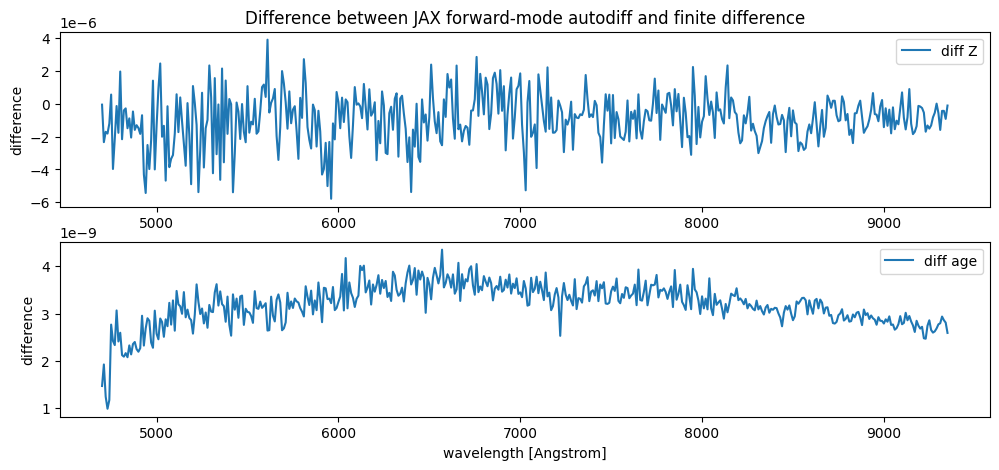

In [27]:
plt.figure(figsize=(12, 5))
plt.subplot(2,1,1)
plt.plot(wave, diff_Z, label='diff Z')
plt.ylabel("difference")
plt.legend()
plt.title("Difference between JAX forward-mode autodiff and finite difference")
plt.subplot(2,1,2)
plt.plot(wave, diff_a, label='diff age')
plt.xlabel("wavelength [Angstrom]")
plt.ylabel("difference")
plt.legend()
plt.show()

In [25]:
print(max(diff_a))

4.3535238e-09


In [26]:
print(max(diff_Z))

3.911555e-06


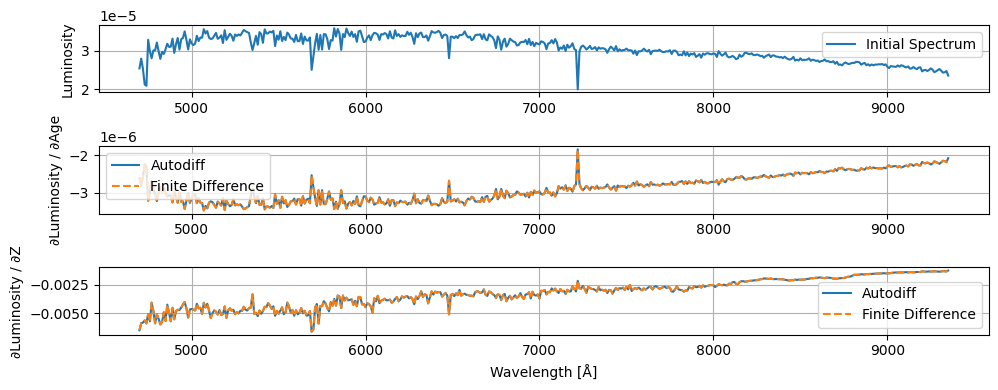

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(3,1,1)
plt.plot(wave, spec0, label="Initial Spectrum")
plt.ylabel("Luminosity")
plt.legend()
plt.grid()
plt.subplot(3,1,2)
plt.plot(wave, dspec, label="Autodiff")
plt.plot(wave, fd, "--", label="Finite Difference")
plt.ylabel("∂Luminosity / ∂Age")
plt.legend()
plt.grid()
plt.subplot(3,1,3)
plt.plot(wave, dspec_Z, label="Autodiff")
plt.plot(wave, fd_Z, "--", label="Finite Difference")
plt.xlabel("Wavelength [Å]")
plt.ylabel("∂Luminosity / ∂Z")
plt.legend(loc="lower right")
plt.grid()
plt.tight_layout()  
plt.savefig("output/optimisation_gradient_on_spectrum.jpg", dpi=1000)
plt.show()